# Custom Method Registration Stress Test (User-Friendly)

This notebook runs custom pruning-method registration with backend-heavy abstraction:

- You define method math
- You register with `@register_method(...)`
- Backend handles tracing, data collection, masking, surgery, and most utilities


## Literature Methods Covered (Registration Stress Set)

Methods tested in this notebook via custom registration:

1. **custom_l2** (weight L2 norm, configurable sum/RMS)
2. **chip** (channel independence via nuclear-norm change)
3. **custom_entropy** (local entropy)
4. **custom_hrank** (rank-based)
5. **custom_class_entropy** (class-aware entropy)
6. **custom_spectral_energy** (spectral criterion)
7. **custom_nisp** (global propagation-style)
8. **custom_senpis** (class-aware global)
9. **custom_tis** (class-aware Taylor style)
10. **custom_reprune** (redundancy clustering style)
11. **custom_thinet** (next-layer reconstruction style)

Note: bundled package methods are intentionally minimal; this notebook is where non-bundled methods are stress-tested.


In [2]:
# --- PHASE 0: BOOTLOADER (Editable Install + Python 3.12 Fix) ---
import sys, os, importlib

# 1. Python 3.12 Fix: Ensure setuptools is fresh for editable installs
!pip install -q --upgrade setuptools pip

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    project_folder_name = "activation-based-pruning"
    base_paths = ["/content/drive/Othercomputers", "/content/drive/MyDrive"]
    project_path = None

    for base in base_paths:
        if os.path.exists(base):
            for root, dirs, files in os.walk(base):
                if project_folder_name in dirs: 
                    project_path = os.path.join(root, project_folder_name); break
        if project_path: break

    if project_path:
        os.chdir(project_path)
        src_path = os.path.join(project_path, "src")
        if src_path not in sys.path: sys.path.insert(0, src_path)
        
        # 2. Restore Editable Install
        !pip install -e .
        
        # 3. Load autoreload BEFORE importing the package (3.12 stability fix)
        try:
            try:
                import imp
            except ImportError:
                from types import ModuleType
                import importlib
                imp = ModuleType('imp')
                imp.reload = importlib.reload
                sys.modules['imp'] = imp
                print("🛠️ Applied Python 3.12 'imp' shim")

            %load_ext autoreload
            %autoreload 2
            import reducnn
            print(f"✅ System Ready! ReduCNN {reducnn.__version__} loaded from: {reducnn.__file__}")
        except Exception as e: print(f"⚠️ Package import failed: {e}")
except ImportError: print("Running in Local Environment (Non-Colab)")


Mounted at /content/drive
Obtaining file:///content/drive/Othercomputers/My%20laptop/activation-based-pruning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ReduCNN (pyproject.toml) ... done
  Created wheel for ReduCNN: filename=reducnn-0.6.6-0.editable-py3-none-any.whl size=3825 sha256=b1c356df02e754b813c864e47dfbb43ecdd116a22dce41be4443044073f3edb9
  Stored in directory: /tmp/pip-ephem-wheel-cache-wgcfyyel/wheels/95/7c/d1/d047f244a296442b073873e350be16b18b7495b817b0632d15
Successfully built ReduCNN
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ReduCNN]
🛠️ Applied Python 3.12 'imp' shim
✅ System Ready! ReduCNN 0.6.6 loaded from: /content/drive/Othercomputers/My laptop/activation-based-pruning/src/reducnn/__init__.py


In [ ]:
# Core setup (user-friendly)
import os
import json
import time
import gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reducnn.backends.factory import get_adapter
from reducnn.pruner import ReduCNNPruner, register_method
from reducnn.visualization import (
    plot_layer_sensitivity,
    plot_metrics_comparison,
    plot_training_history,
    plot_rank_correlation,
    plot_score_distributions,
    plot_decision_agreement,
    plot_inference_gallery,
)

SAVE_ROOT = Path("saved_models")
DATASET_KEY = "cifar-10"
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")

# --- 1) Choose one preset ---
# quick: fastest smoke test
# balanced: recommended for regular experimentation
# full: slower, stronger calibration coverage
EXPERIMENT_PRESET = "balanced"  # quick | balanced | full

# --- 2) Choose model target ---
# Supported: resnet18, vgg16, densenet121, mobilenet_v2
MODEL_TARGET = "resnet18"

# --- 3) Pruning level ---
PRUNE_RATIO = 0.30

# --- 4) Pretrained policy ---
REQUIRE_PRETRAINED_TORCH = True
REQUIRE_PRETRAINED_KERAS = False

# --- 5) Checkpoint persistence policy ---
AUTO_TRAIN_BASELINE_IF_MISSING = True
FORCE_RETRAIN_BASELINE = False  # True: ignore existing checkpoint and train/save a fresh baseline
SAVE_BASELINE_WHEN_MISSING = True
SAVE_RAW_PRUNED_CHECKPOINTS = True
SAVE_HEALED_CHECKPOINTS = True
RUN_HEALING_FOR_ALL_METHODS = True
CAPTURE_EFFICIENCY_METRICS = True

# --- 6) Deep analysis / healing visuals ---
RUN_DEEP_ANALYSIS = True
ANALYSIS_BACKENDS = ["pytorch", "keras"]
ANALYSIS_METHOD = "custom_nisp"
ANALYSIS_COMPARE_METHODS = ["l1_norm", "mean_abs_act", "apoz", "custom_l2", "custom_nisp", "custom_senpis", "custom_tis"]

# Preset table (single place controlling runtime/quality tradeoff)
_PRESET_CFG = {
    "quick": {
        "calib_batches": 1,
        "max_samples": 256,
        "batch_size": 64,
        "chip_max_spatial": 16,
        "finetune_epochs": 1,
        "ft_train_samples": 1024,
        "ft_val_samples": 512,
        "ft_test_samples": 1024,
        "baseline_bootstrap_epochs": 1,
    },
    "balanced": {
        "calib_batches": 2,
        "max_samples": 1024,
        "batch_size": 64,
        "chip_max_spatial": 24,
        "finetune_epochs": 3,
        "ft_train_samples": 4096,
        "ft_val_samples": 1000,
        "ft_test_samples": 2000,
        "baseline_bootstrap_epochs": 2,
    },
    "full": {
        "calib_batches": 4,
        "max_samples": 2048,
        "batch_size": 64,
        "chip_max_spatial": 32,
        "finetune_epochs": 6,
        "ft_train_samples": 10000,
        "ft_val_samples": 2000,
        "ft_test_samples": 5000,
        "baseline_bootstrap_epochs": 4,
    },
}
if EXPERIMENT_PRESET not in _PRESET_CFG:
    raise ValueError(f"Unknown EXPERIMENT_PRESET='{EXPERIMENT_PRESET}'. Use one of: {list(_PRESET_CFG.keys())}")

CALIB_BATCHES = int(_PRESET_CFG[EXPERIMENT_PRESET]["calib_batches"])
MAX_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["max_samples"])
BATCH_SIZE = int(_PRESET_CFG[EXPERIMENT_PRESET]["batch_size"])
CHIP_MAX_SPATIAL = int(_PRESET_CFG[EXPERIMENT_PRESET]["chip_max_spatial"])
FINETUNE_EPOCHS = int(_PRESET_CFG[EXPERIMENT_PRESET]["finetune_epochs"])
FT_TRAIN_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["ft_train_samples"])
FT_VAL_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["ft_val_samples"])
FT_TEST_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["ft_test_samples"])
BASELINE_BOOTSTRAP_EPOCHS = int(_PRESET_CFG[EXPERIMENT_PRESET]["baseline_bootstrap_epochs"])

TORCH_MODEL_REQUEST = MODEL_TARGET
KERAS_MODEL_REQUEST = MODEL_TARGET

BUILTIN_METHODS = [
    "l1_norm",
    "mean_abs_act",
    "apoz",
]

CUSTOM_METHODS = [
    "custom_l2",
    "chip",
    "custom_entropy",
    "custom_hrank",
    "custom_class_entropy",
    "custom_spectral_energy",
    "custom_nisp",
    "custom_senpis",
    "custom_tis",
    "custom_reprune",
    "custom_thinet",
]

# This is the actual matrix used for efficiency ranking. It must include the
# bundled baselines as well as registered custom methods; otherwise the hybrid
# notebook cannot compare simple local proxies against complex methods.
METHOD_MATRIX_METHODS = list(dict.fromkeys(BUILTIN_METHODS + CUSTOM_METHODS))

GLOBAL_METHODS = {"chip", "custom_nisp", "custom_senpis", "custom_tis", "custom_reprune", "custom_thinet"}

EPS = 1e-12
BINS = 24

print("=== Experiment Config ===")
print(f"Run stamp: {RUN_STAMP}")
print(f"Preset: {EXPERIMENT_PRESET}")
print(f"Model target: {MODEL_TARGET}")
print(f"Prune ratio: {PRUNE_RATIO}")
print(f"Calibration: batches={CALIB_BATCHES}, max_samples={MAX_SAMPLES}, batch_size={BATCH_SIZE}")
print(f"Recovery: finetune_epochs={FINETUNE_EPOCHS}, train/val/test={FT_TRAIN_SAMPLES}/{FT_VAL_SAMPLES}/{FT_TEST_SAMPLES}")
print(f"Baseline bootstrap epochs: {BASELINE_BOOTSTRAP_EPOCHS}")
print(f"CHIP max spatial: {CHIP_MAX_SPATIAL}")
print(f"Require pretrained torch={REQUIRE_PRETRAINED_TORCH}, keras={REQUIRE_PRETRAINED_KERAS}")
print(f"Persistence: force_retrain_baseline={FORCE_RETRAIN_BASELINE}, baseline_if_missing={SAVE_BASELINE_WHEN_MISSING}, raw={SAVE_RAW_PRUNED_CHECKPOINTS}, healed={SAVE_HEALED_CHECKPOINTS}")
print(f"Efficiency metrics: healing_all_methods={RUN_HEALING_FOR_ALL_METHODS}, capture={CAPTURE_EFFICIENCY_METRICS}")
print("Method matrix:", METHOD_MATRIX_METHODS)


=== Experiment Config ===
Run stamp: 20260324_110633
Preset: balanced
Model target: resnet18
Prune ratio: 0.3
Calibration: batches=2, max_samples=1024, batch_size=64
Recovery: finetune_epochs=3, train/val/test=4096/1000/2000
Baseline bootstrap epochs: 2
CHIP max spatial: 24
Require pretrained torch=True, keras=False
Persistence: baseline_if_missing=True, raw=True, healed=True
Methods: ['custom_l2', 'chip', 'custom_entropy', 'custom_hrank', 'custom_class_entropy', 'custom_spectral_energy', 'custom_nisp', 'custom_senpis', 'custom_tis', 'custom_reprune', 'custom_thinet']


In [ ]:
# Helpers: checkpoints + data

def _latest_file(paths):
    files = [p for p in paths if p.exists()]
    if not files:
        return None
    return str(sorted(files, key=lambda p: p.stat().st_mtime, reverse=True)[0])


def _ckpt_ext(backend: str) -> str:
    backend = backend.lower().strip()
    return ".pth" if backend == "pytorch" else ".weights.h5"


def build_checkpoint_path(stage: str, backend: str, model_name: str, method: str = None,
                          suffix: str = None, run_stamp: str = RUN_STAMP, dataset_key: str = DATASET_KEY):
    root = SAVE_ROOT / stage / backend / dataset_key / model_name
    if method:
        root = root / method
    root.mkdir(parents=True, exist_ok=True)

    fname = f"{run_stamp}_{backend}_{model_name}"
    if method:
        fname += f"_{method}"
    if suffix:
        fname += f"_{suffix}"
    fname += _ckpt_ext(backend)
    return str(root / fname)


def find_latest_baseline_checkpoint(backend: str, model_request: str, dataset_key: str = DATASET_KEY):
    backend = backend.lower().strip()
    model_l = str(model_request).lower().strip()
    if backend == "pytorch":
        exts = [".pth", ".pt"]
        aliases = {
            "resnet18": ["resnet18"],
            "vgg16": ["vgg16"],
            "densenet121": ["densenet121", "densenet", "desnsenet121"],
            "mobilenet_v2": ["mobilenet_v2", "mobilenetv2", "mobilenet"],
        }
    else:
        exts = [".weights.h5", ".h5"]
        aliases = {
            "resnet18": ["resnet18"],
            "vgg16": ["vgg16"],
            "densenet121": ["densenet121", "densenet"],
            "mobilenet_v2": ["mobilenet_v2", "mobilenetv2", "mobilenet"],
            "resnet": ["resnet", "resnet18"],
            "mobilenet": ["mobilenet", "mobilenet_v2"],
            "densenet": ["densenet", "densenet121"],
        }

    exact_dir = SAVE_ROOT / "baselines" / backend / dataset_key / model_request
    exact_candidates = []
    for ext in exts:
        exact_candidates.extend(exact_dir.glob(f"*{ext}"))
    exact = _latest_file(exact_candidates)
    if exact:
        return exact

    scan_root = SAVE_ROOT / "baselines" / backend / dataset_key
    if not scan_root.exists():
        return None

    all_candidates = []
    for ext in exts:
        all_candidates.extend(scan_root.rglob(f"*{ext}"))
    if not all_candidates:
        return None

    cand_aliases = aliases.get(model_l, [model_l])

    def _rank_key(p):
        s = str(p).lower().replace('/', '\\')
        alias_hits = [i for i, a in enumerate(cand_aliases) if a in s]
        has_any = len(alias_hits) > 0
        has_exact = model_l in s
        has_exact_dir = f"\\{model_l}\\" in s
        alias_idx = min(alias_hits) if alias_hits else 999
        return (
            not has_any,
            not has_exact_dir,
            not has_exact,
            alias_idx,
            -p.stat().st_mtime,
        )

    ranked = sorted(all_candidates, key=_rank_key)
    if not ranked:
        return None
    if not any(a in str(ranked[0]).lower() for a in cand_aliases):
        return None
    return str(ranked[0])


def make_torch_calib_loader(max_samples: int = MAX_SAMPLES, batch_size: int = BATCH_SIZE):
    import torchvision
    import torchvision.transforms as transforms
    from torch.utils.data import DataLoader, Subset

    tfm = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
    idx = list(range(min(max_samples, len(trainset))))
    subset = Subset(trainset, idx)
    return DataLoader(subset, batch_size=batch_size, shuffle=False)


def make_keras_calib_loader(max_samples: int = MAX_SAMPLES, batch_size: int = BATCH_SIZE):
    import tensorflow as tf

    (x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
    x = x_train[:max_samples].astype("float32") / 255.0
    y = y_train[:max_samples].astype("int32").reshape(-1)
    ds = tf.data.Dataset.from_tensor_slices((x, y)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def make_torch_recovery_loaders(train_samples: int = FT_TRAIN_SAMPLES,
                                val_samples: int = FT_VAL_SAMPLES,
                                test_samples: int = FT_TEST_SAMPLES,
                                batch_size: int = BATCH_SIZE):
    import torchvision
    import torchvision.transforms as transforms
    from torch.utils.data import DataLoader, Subset

    tfm = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
    testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)

    t_end = min(train_samples, len(trainset))
    v_start = t_end
    v_end = min(v_start + val_samples, len(trainset))
    te_end = min(test_samples, len(testset))

    train_loader = DataLoader(Subset(trainset, list(range(0, t_end))), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(trainset, list(range(v_start, v_end))), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(Subset(testset, list(range(0, te_end))), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def make_keras_recovery_loaders(train_samples: int = FT_TRAIN_SAMPLES,
                                val_samples: int = FT_VAL_SAMPLES,
                                test_samples: int = FT_TEST_SAMPLES,
                                batch_size: int = BATCH_SIZE):
    import tensorflow as tf

    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype("float32") / 255.0
    y_train = y_train.astype("int32").reshape(-1)
    x_test = x_test.astype("float32") / 255.0
    y_test = y_test.astype("int32").reshape(-1)

    t_end = min(train_samples, len(x_train))
    v_start = t_end
    v_end = min(v_start + val_samples, len(x_train))
    te_end = min(test_samples, len(x_test))

    train_ds = tf.data.Dataset.from_tensor_slices((x_train[:t_end], y_train[:t_end])).shuffle(min(t_end, 4096)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((x_train[v_start:v_end], y_train[v_start:v_end])).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((x_test[:te_end], y_test[:te_end])).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds, test_ds


def ensure_baseline_checkpoint(adapter, backend: str, model_name: str, found_ckpt: str,
                               input_shape, num_classes: int,
                               require_pretrained: bool):
    backend = backend.lower().strip()
    force_retrain = bool(globals().get("FORCE_RETRAIN_BASELINE", False))
    if found_ckpt and os.path.exists(found_ckpt) and not force_retrain:
        return found_ckpt, False

    if force_retrain:
        msg = f"[baseline] Force retrain enabled for {backend}:{model_name}."
        if found_ckpt and os.path.exists(found_ckpt):
            msg += f" Existing checkpoint will be ignored: {found_ckpt}"
        print(msg)
    elif require_pretrained and not AUTO_TRAIN_BASELINE_IF_MISSING:
        raise FileNotFoundError(
            f"No pretrained baseline checkpoint found for {model_name} under {SAVE_ROOT}/baselines/{backend}/{DATASET_KEY}"
        )

    if not AUTO_TRAIN_BASELINE_IF_MISSING and not force_retrain:
        return found_ckpt, False

    if not force_retrain:
        print(f"[baseline] Missing baseline for {backend}:{model_name}. Bootstrapping...")
    model = adapter.get_model(model_name, input_shape=input_shape, num_classes=num_classes, pretrained=False)

    if BASELINE_BOOTSTRAP_EPOCHS > 0:
        if backend == "pytorch":
            tr, va, _ = make_torch_recovery_loaders()
        else:
            tr, va, _ = make_keras_recovery_loaders()
        adapter.train(
            model,
            tr,
            epochs=BASELINE_BOOTSTRAP_EPOCHS,
            val_loader=va,
            name=f"{backend}_{model_name}_baseline_bootstrap",
            plot=False,
        )

    if SAVE_BASELINE_WHEN_MISSING:
        save_path = build_checkpoint_path(
            stage="baselines",
            backend=backend,
            model_name=model_name,
            suffix="baseline",
            run_stamp=RUN_STAMP,
        )
        adapter.save_checkpoint(model, save_path)
        print(f"[baseline] Saved: {save_path}")
        return save_path, True

    return found_ckpt, True


def _mask_keep_stats(masks):
    if not masks:
        return 0, 0.0, 0.0
    keep = [float(np.mean(np.asarray(v, dtype=np.float64))) for v in masks.values() if np.asarray(v).size > 0]
    if not keep:
        return len(masks), 0.0, 0.0
    return len(masks), float(np.mean(keep)), float(np.min(keep))

# --- Efficiency metric helpers for hybrid selection ---
def _safe_float(x, default=None):
    try:
        if x is None:
            return default
        v = float(x)
        if np.isnan(v) or np.isinf(v):
            return default
        return v
    except Exception:
        return default


def _round_or_none(x, ndigits=4):
    v = _safe_float(x, None)
    return None if v is None else round(v, ndigits)


def _safe_evaluate(adapter, model, loader):
    try:
        return _safe_float(adapter.evaluate(model, loader), None)
    except Exception as exc:
        print(f"[metrics] evaluate failed: {type(exc).__name__}: {exc}")
        return None


def _safe_stats(adapter, model, loader):
    try:
        flops, params = adapter.get_stats(model, loader)
        return _safe_float(flops, 0.0), _safe_float(params, 0.0)
    except Exception as exc:
        print(f"[metrics] stats failed: {type(exc).__name__}: {exc}")
        return 0.0, 0.0


def _reduction_pct(before, after):
    b = _safe_float(before, None)
    a = _safe_float(after, None)
    if b is None or a is None or b <= 0:
        return None
    return 100.0 * (1.0 - (a / b))


def _delta(after, before):
    a = _safe_float(after, None)
    b = _safe_float(before, None)
    if a is None or b is None:
        return None
    return a - b


def _metrics_payload(prefix, acc, flops, params, baseline_acc, baseline_flops, baseline_params):
    return {
        f"{prefix}_accuracy_pct": _round_or_none(acc, 4),
        f"{prefix}_accuracy_delta_pct": _round_or_none(_delta(acc, baseline_acc), 4),
        f"{prefix}_flops": _round_or_none(flops, 4),
        f"{prefix}_params": _round_or_none(params, 4),
        f"{prefix}_flops_reduction_pct": _round_or_none(_reduction_pct(baseline_flops, flops), 4),
        f"{prefix}_params_reduction_pct": _round_or_none(_reduction_pct(baseline_params, params), 4),
    }


def _save_json_records(rows, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(rows, f, indent=2, default=str)
    return path


def _rank_efficiency(summary_df):
    if summary_df.empty:
        return summary_df.copy()
    df = summary_df.copy()
    for col in [
        "prune_time_sec", "score_time_sec", "mask_build_time_sec", "surgery_time_sec",
        "method_cost_time_sec", "prune_pipeline_time_sec", "heal_time_sec", "healed_accuracy_delta_pct",
        "healed_flops_reduction_pct", "healed_params_reduction_pct",
        "raw_pruned_accuracy_delta_pct", "raw_pruned_flops_reduction_pct",
    ]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")
    if "method_cost_time_sec" in df.columns:
        df["prune_time_sec"] = df["method_cost_time_sec"].combine_first(df["prune_time_sec"])
    df["simplicity_time_sec"] = df["prune_time_sec"].fillna(0.0) + df["heal_time_sec"].fillna(0.0)
    df["efficiency_accuracy_delta_pct"] = df["healed_accuracy_delta_pct"].combine_first(df["raw_pruned_accuracy_delta_pct"])
    df["efficiency_flops_reduction_pct"] = df["healed_flops_reduction_pct"].combine_first(df["raw_pruned_flops_reduction_pct"])
    df["efficiency_params_reduction_pct"] = df["healed_params_reduction_pct"].combine_first(df["raw_pruned_params_reduction_pct"] if "raw_pruned_params_reduction_pct" in df.columns else pd.Series(np.nan, index=df.index))
    df["simplicity_time_bucket_sec"] = df["simplicity_time_sec"].round(1)
    df["efficiency_rank_basis"] = "overall method cost asc (score+mask+surgery), accuracy delta desc, FLOPs reduction desc, params reduction desc"
    df = df.sort_values(
        ["backend", "status", "simplicity_time_bucket_sec", "efficiency_accuracy_delta_pct", "efficiency_flops_reduction_pct", "efficiency_params_reduction_pct", "method"],
        ascending=[True, True, True, False, False, False, True],
        na_position="last",
    ).reset_index(drop=True)
    df["efficiency_rank"] = df.groupby(["backend", "status"], dropna=False).cumcount() + 1
    return df



In [5]:
# --- Custom methods: backend does heavy lifting, methods focus on math ---


def _tools(kwargs):
    t = kwargs.get("tools", None)
    if t is None:
        raise ValueError("Backend tools were not provided. Upgrade reducers backend integration.")
    return t


def _max_batches(kwargs):
    return int(kwargs.get("calib_batches", kwargs.get("prune_batches", CALIB_BATCHES)))


@register_method("custom_l2", framework="torch")
@register_method("custom_l2", framework="keras")
def custom_l2_score(layer, **kwargs):
    tools = _tools(kwargs)
    mode = str(kwargs.get("l2_mode", "sum")).lower().strip()
    return np.asarray(tools.weight_l2(layer, mode=mode), dtype=np.float64).reshape(-1)


@register_method("chip", framework="torch")
@register_method("chip", framework="keras")
def chip_score(layer, **kwargs):
    """CHIP-style channel independence score (paper-aligned correlation form)."""
    from reducnn.pruner.chip import chip_channel_independence_scores

    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None

    channel_axis = 1 if tools.framework == "torch" else -1
    spatial_total = int(A.shape[2] * A.shape[3]) if tools.framework == "torch" else int(A.shape[1] * A.shape[2])
    max_spatial = int(kwargs.get("chip_max_spatial", spatial_total))
    max_spatial = max(1, min(max_spatial, spatial_total))

    s = chip_channel_independence_scores(
        A,
        channel_axis=channel_axis,
        max_spatial=max_spatial,
    )
    return np.asarray(s, dtype=np.float64).reshape(-1)


@register_method("custom_entropy", framework="torch")
@register_method("custom_entropy", framework="keras")
def custom_entropy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None
    X = tools.channel_matrix(np.maximum(A, 0.0))
    bins = int(kwargs.get("bins", BINS))
    out = [tools.entropy_1d(X[c], bins=bins, eps=EPS) for c in range(X.shape[0])]
    return np.asarray(out, dtype=np.float64)


@register_method("custom_hrank", framework="torch")
@register_method("custom_hrank", framework="keras")
def custom_hrank_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.rank_scores(A, max_samples=int(kwargs.get("max_rank_samples", 32))), dtype=np.float64).reshape(-1)


@register_method("custom_class_entropy", framework="torch")
@register_method("custom_class_entropy", framework="keras")
def custom_class_entropy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, Y = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=True)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)

    NC = tools.pooled_nc(A)
    classes = np.unique(Y)
    if classes.size == 0:
        return np.zeros((NC.shape[1],), dtype=np.float64)

    out = np.zeros((NC.shape[1],), dtype=np.float64)
    bins = int(kwargs.get("bins", BINS))
    for c in range(NC.shape[1]):
        vals = []
        for cls in classes:
            idx = np.where(Y == cls)[0]
            if idx.size:
                vals.append(tools.entropy_1d(NC[idx, c], bins=bins, eps=EPS))
        out[c] = float(np.mean(vals)) if vals else 0.0
    return out


@register_method("custom_spectral_energy", framework="torch")
@register_method("custom_spectral_energy", framework="keras")
def custom_spectral_energy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.spectral_energy_scores(A, max_samples=int(kwargs.get("max_fft_samples", 32))), dtype=np.float64).reshape(-1)


@register_method("custom_nisp", framework="torch")
@register_method("custom_nisp", framework="keras")
def custom_nisp_score(layer, **kwargs):
    tools = _tools(kwargs)
    lname = kwargs.get("layer_name", None)
    if lname is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    score_map = tools.nisp_score_map(max_batches=_max_batches(kwargs))
    s = score_map.get(lname, None)
    if s is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(s, dtype=np.float64).reshape(-1)


@register_method("custom_senpis", framework="torch")
@register_method("custom_senpis", framework="keras")
def custom_senpis_score(layer, **kwargs):
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    base = np.mean(mat, axis=0)
    disc = tools.class_entropy_discriminability(mat)
    return np.asarray(base * (1.0 + disc), dtype=np.float64).reshape(-1)


@register_method("custom_tis", framework="torch")
@register_method("custom_tis", framework="keras")
def custom_tis_score(layer, **kwargs):
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    pct = float(kwargs.get("tis_percentile", 75.0))
    return np.asarray(tools.tis_threshold_aggregate(mat, percentile=pct), dtype=np.float64).reshape(-1)


@register_method("custom_reprune", framework="torch")
@register_method("custom_reprune", framework="keras")
def custom_reprune_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.reprune_representative_scores(A), dtype=np.float64).reshape(-1)


@register_method("custom_thinet", framework="torch")
@register_method("custom_thinet", framework="keras")
def custom_thinet_score(layer, **kwargs):
    tools = _tools(kwargs)
    alpha = np.asarray(tools.thinet_alpha(layer), dtype=np.float64).reshape(-1)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return alpha
    return np.asarray(tools.thinet_reconstruction_scores(A, alpha), dtype=np.float64).reshape(-1)


print("Custom methods registered. Backend tools handle tracing, caching, activations, and propagation.")


Custom methods registered. Backend tools handle tracing, caching, activations, and propagation.


## Part A: PyTorch (loop all custom methods, no plots)

In [ ]:
# PyTorch run
import torch

torch_cfg = {
    "backend": "pytorch",
    "model_type": TORCH_MODEL_REQUEST,
    "input_shape": (3, 32, 32),
    "num_classes": 10,
    "prune_batches": CALIB_BATCHES,
    "chip_max_spatial": CHIP_MAX_SPATIAL,
    "lr": 1e-4,
    "torch_restore_best": True,
    "torch_reduce_lr_on_plateau": True,
    "torch_lr_patience": 1,
    "torch_lr_reduce_factor": 0.5,
    "torch_min_lr": 1e-6,
}

torch_adapter = get_adapter(None, torch_cfg)
torch_loader = make_torch_calib_loader(max_samples=MAX_SAMPLES, batch_size=BATCH_SIZE)
torch_train_loader, torch_val_loader, torch_test_loader = make_torch_recovery_loaders(batch_size=BATCH_SIZE)

torch_ckpt = find_latest_baseline_checkpoint("pytorch", TORCH_MODEL_REQUEST)
torch_ckpt, torch_baseline_created = ensure_baseline_checkpoint(
    adapter=torch_adapter,
    backend="pytorch",
    model_name=TORCH_MODEL_REQUEST,
    found_ckpt=torch_ckpt,
    input_shape=(3, 32, 32),
    num_classes=10,
    require_pretrained=REQUIRE_PRETRAINED_TORCH,
)
print("PyTorch baseline checkpoint used:", torch_ckpt)


def _load_torch_baseline():
    m = torch_adapter.get_model(TORCH_MODEL_REQUEST, input_shape=(3, 32, 32), num_classes=10, pretrained=False)
    if torch_ckpt:
        torch_adapter.load_checkpoint(m, torch_ckpt)
    return m


torch_baseline_for_metrics = _load_torch_baseline()
torch_baseline_accuracy = _safe_evaluate(torch_adapter, torch_baseline_for_metrics, torch_test_loader)
torch_baseline_flops, torch_baseline_params = _safe_stats(torch_adapter, torch_baseline_for_metrics, torch_test_loader)
print(f"[torch baseline] acc={torch_baseline_accuracy} flops={torch_baseline_flops} params={torch_baseline_params}")
del torch_baseline_for_metrics
gc.collect()

torch_rows = []
for method in METHOD_MATRIX_METHODS:
    scope = "global" if method in GLOBAL_METHODS else "local"
    t0 = time.time()
    status, err = "ok", ""
    n_layers, mean_keep, min_keep, duration = 0, 0.0, 0.0, 0.0
    raw_ckpt, healed_ckpt = "", ""
    raw_acc = raw_flops = raw_params = None
    healed_acc = healed_flops = healed_params = None
    heal_time = 0.0
    prune_timing = {}

    try:
        model = _load_torch_baseline()
        pruner = ReduCNNPruner(method=method, scope=scope, config={"backend": "pytorch", "chip_max_spatial": CHIP_MAX_SPATIAL, "ratio": PRUNE_RATIO})
        raw_ckpt = build_checkpoint_path(
            stage="pruned_raw",
            backend="pytorch",
            model_name=TORCH_MODEL_REQUEST,
            method=method,
            suffix="raw",
            run_stamp=RUN_STAMP,
        ) if SAVE_RAW_PRUNED_CHECKPOINTS else None
        pruned_model, masks, duration = pruner.prune_custom_model(
            model,
            torch_loader,
            ratio=PRUNE_RATIO,
            save_pruned_path=raw_ckpt,
        )
        n_layers, mean_keep, min_keep = _mask_keep_stats(masks)
        prune_timing = dict(getattr(pruner, "last_timing", {}) or {})

        raw_acc = _safe_evaluate(torch_adapter, pruned_model, torch_test_loader)
        raw_flops, raw_params = _safe_stats(torch_adapter, pruned_model, torch_test_loader)

        if RUN_HEALING_FOR_ALL_METHODS:
            heal_t0 = time.time()
            if FINETUNE_EPOCHS > 0:
                torch_adapter.train(
                    pruned_model,
                    torch_train_loader,
                    FINETUNE_EPOCHS,
                    name=f"pytorch_{TORCH_MODEL_REQUEST}_{method}_healing",
                    val_loader=torch_val_loader,
                    plot=False,
                )
            heal_time = time.time() - heal_t0
            healed_acc = _safe_evaluate(torch_adapter, pruned_model, torch_test_loader)
            healed_flops, healed_params = _safe_stats(torch_adapter, pruned_model, torch_test_loader)
            if SAVE_HEALED_CHECKPOINTS:
                healed_ckpt = build_checkpoint_path(
                    stage="fine_tuned",
                    backend="pytorch",
                    model_name=TORCH_MODEL_REQUEST,
                    method=method,
                    suffix="healed",
                    run_stamp=RUN_STAMP,
                )
                torch_adapter.save_checkpoint(pruned_model, healed_ckpt)
        else:
            healed_acc, healed_flops, healed_params = raw_acc, raw_flops, raw_params
    except Exception as e:
        status, err = "error", f"{type(e).__name__}: {e}"
        raw_ckpt, healed_ckpt = "", ""
    finally:
        gc.collect()

    row = {
        "backend": "pytorch",
        "model": TORCH_MODEL_REQUEST,
        "dataset": DATASET_KEY,
        "method": method,
        "scope": scope,
        "prune_ratio": PRUNE_RATIO,
        "status": status,
        "error": err,
        "layers_scored": int(n_layers),
        "mean_keep_ratio": round(mean_keep, 4),
        "min_keep_ratio": round(min_keep, 4),
        "baseline_accuracy_pct": _round_or_none(torch_baseline_accuracy, 4),
        "baseline_flops": _round_or_none(torch_baseline_flops, 4),
        "baseline_params": _round_or_none(torch_baseline_params, 4),
        "prune_time_sec": round(duration, 3),
        "score_time_sec": round(float(prune_timing.get("score_time_sec", 0.0)), 3),
        "mask_build_time_sec": round(float(prune_timing.get("mask_build_time_sec", 0.0)), 3),
        "surgery_time_sec": round(float(prune_timing.get("surgery_time_sec", 0.0)), 3),
        "method_cost_time_sec": round(float(prune_timing.get("method_cost_time_sec", duration or 0.0)), 3),
        "topology_time_sec": round(float(prune_timing.get("topology_time_sec", 0.0)), 3),
        "prune_pipeline_time_sec": round(float(prune_timing.get("prune_pipeline_time_sec", duration or 0.0)), 3),
        "heal_time_sec": round(heal_time, 3),
        "simplicity_time_sec": round(float(duration or 0.0) + float(heal_time or 0.0), 3),
        "wall_time_sec": round(time.time() - t0, 3),
        "baseline_ckpt_used": torch_ckpt or "",
        "baseline_created": bool(torch_baseline_created),
        "raw_pruned_ckpt": raw_ckpt or "",
        "healed_ckpt": healed_ckpt or "",
    }
    row.update(_metrics_payload("raw_pruned", raw_acc, raw_flops, raw_params, torch_baseline_accuracy, torch_baseline_flops, torch_baseline_params))
    row.update(_metrics_payload("healed", healed_acc, healed_flops, healed_params, torch_baseline_accuracy, torch_baseline_flops, torch_baseline_params))
    torch_rows.append(row)
    print(f"[torch] {method:<22} ({scope}) -> {status}")

torch_summary = pd.DataFrame(torch_rows).sort_values(["status", "method"]).reset_index(drop=True)
torch_summary


## Part B: Keras (loop all custom methods, no plots)

In [ ]:
# Keras run
import tensorflow as tf

keras_cfg = {
    "backend": "keras",
    "model_type": KERAS_MODEL_REQUEST,
    "input_shape": (32, 32, 3),
    "num_classes": 10,
    "prune_batches": CALIB_BATCHES,
    "keras_weights": "none",
    "chip_max_spatial": CHIP_MAX_SPATIAL,
    "keras_lr": 1e-4,
    "keras_restore_best": True,
    "keras_reduce_lr_on_plateau": True,
    "keras_early_stop_patience": 2,
    "keras_lr_patience": 1,
    "keras_lr_reduce_factor": 0.5,
    "keras_min_lr": 1e-6,
}

keras_adapter = get_adapter(None, keras_cfg)
keras_loader = make_keras_calib_loader(max_samples=MAX_SAMPLES, batch_size=BATCH_SIZE)
keras_train_loader, keras_val_loader, keras_test_loader = make_keras_recovery_loaders(batch_size=BATCH_SIZE)

keras_ckpt = find_latest_baseline_checkpoint("keras", KERAS_MODEL_REQUEST)
keras_ckpt, keras_baseline_created = ensure_baseline_checkpoint(
    adapter=keras_adapter,
    backend="keras",
    model_name=KERAS_MODEL_REQUEST,
    found_ckpt=keras_ckpt,
    input_shape=(32, 32, 3),
    num_classes=10,
    require_pretrained=REQUIRE_PRETRAINED_KERAS,
)
print("Keras baseline checkpoint used:", keras_ckpt)


def _load_keras_baseline():
    m = keras_adapter.get_model(KERAS_MODEL_REQUEST, input_shape=(32, 32, 3), num_classes=10, pretrained=False)
    if keras_ckpt:
        keras_adapter.load_checkpoint(m, keras_ckpt)
    return m


keras_baseline_for_metrics = _load_keras_baseline()
keras_baseline_accuracy = _safe_evaluate(keras_adapter, keras_baseline_for_metrics, keras_test_loader)
keras_baseline_flops, keras_baseline_params = _safe_stats(keras_adapter, keras_baseline_for_metrics, keras_test_loader)
print(f"[keras baseline] acc={keras_baseline_accuracy} flops={keras_baseline_flops} params={keras_baseline_params}")
try:
    tf.keras.backend.clear_session()
except Exception:
    pass
gc.collect()

keras_rows = []
for method in METHOD_MATRIX_METHODS:
    scope = "global" if method in GLOBAL_METHODS else "local"
    t0 = time.time()
    status, err = "ok", ""
    n_layers, mean_keep, min_keep, duration = 0, 0.0, 0.0, 0.0
    raw_ckpt, healed_ckpt = "", ""
    raw_acc = raw_flops = raw_params = None
    healed_acc = healed_flops = healed_params = None
    heal_time = 0.0
    prune_timing = {}

    try:
        model = _load_keras_baseline()
        pruner = ReduCNNPruner(method=method, scope=scope, config={"backend": "keras", "chip_max_spatial": CHIP_MAX_SPATIAL, "ratio": PRUNE_RATIO})
        raw_ckpt = build_checkpoint_path(
            stage="pruned_raw",
            backend="keras",
            model_name=KERAS_MODEL_REQUEST,
            method=method,
            suffix="raw",
            run_stamp=RUN_STAMP,
        ) if SAVE_RAW_PRUNED_CHECKPOINTS else None
        pruned_model, masks, duration = pruner.prune_custom_model(
            model,
            keras_loader,
            ratio=PRUNE_RATIO,
            save_pruned_path=raw_ckpt,
        )
        n_layers, mean_keep, min_keep = _mask_keep_stats(masks)
        prune_timing = dict(getattr(pruner, "last_timing", {}) or {})

        raw_acc = _safe_evaluate(keras_adapter, pruned_model, keras_test_loader)
        raw_flops, raw_params = _safe_stats(keras_adapter, pruned_model, keras_test_loader)

        if RUN_HEALING_FOR_ALL_METHODS:
            heal_t0 = time.time()
            if FINETUNE_EPOCHS > 0:
                keras_adapter.train(
                    pruned_model,
                    keras_train_loader,
                    FINETUNE_EPOCHS,
                    name=f"keras_{KERAS_MODEL_REQUEST}_{method}_healing",
                    val_loader=keras_val_loader,
                    plot=False,
                )
            heal_time = time.time() - heal_t0
            healed_acc = _safe_evaluate(keras_adapter, pruned_model, keras_test_loader)
            healed_flops, healed_params = _safe_stats(keras_adapter, pruned_model, keras_test_loader)
            if SAVE_HEALED_CHECKPOINTS:
                healed_ckpt = build_checkpoint_path(
                    stage="fine_tuned",
                    backend="keras",
                    model_name=KERAS_MODEL_REQUEST,
                    method=method,
                    suffix="healed",
                    run_stamp=RUN_STAMP,
                )
                keras_adapter.save_checkpoint(pruned_model, healed_ckpt)
        else:
            healed_acc, healed_flops, healed_params = raw_acc, raw_flops, raw_params
    except Exception as e:
        status, err = "error", f"{type(e).__name__}: {e}"
        raw_ckpt, healed_ckpt = "", ""
    finally:
        try:
            tf.keras.backend.clear_session()
        except Exception:
            pass
        gc.collect()

    row = {
        "backend": "keras",
        "model": KERAS_MODEL_REQUEST,
        "dataset": DATASET_KEY,
        "method": method,
        "scope": scope,
        "prune_ratio": PRUNE_RATIO,
        "status": status,
        "error": err,
        "layers_scored": int(n_layers),
        "mean_keep_ratio": round(mean_keep, 4),
        "min_keep_ratio": round(min_keep, 4),
        "baseline_accuracy_pct": _round_or_none(keras_baseline_accuracy, 4),
        "baseline_flops": _round_or_none(keras_baseline_flops, 4),
        "baseline_params": _round_or_none(keras_baseline_params, 4),
        "prune_time_sec": round(duration, 3),
        "score_time_sec": round(float(prune_timing.get("score_time_sec", 0.0)), 3),
        "mask_build_time_sec": round(float(prune_timing.get("mask_build_time_sec", 0.0)), 3),
        "surgery_time_sec": round(float(prune_timing.get("surgery_time_sec", 0.0)), 3),
        "method_cost_time_sec": round(float(prune_timing.get("method_cost_time_sec", duration or 0.0)), 3),
        "topology_time_sec": round(float(prune_timing.get("topology_time_sec", 0.0)), 3),
        "prune_pipeline_time_sec": round(float(prune_timing.get("prune_pipeline_time_sec", duration or 0.0)), 3),
        "heal_time_sec": round(heal_time, 3),
        "simplicity_time_sec": round(float(duration or 0.0) + float(heal_time or 0.0), 3),
        "wall_time_sec": round(time.time() - t0, 3),
        "baseline_ckpt_used": keras_ckpt or "",
        "baseline_created": bool(keras_baseline_created),
        "raw_pruned_ckpt": raw_ckpt or "",
        "healed_ckpt": healed_ckpt or "",
    }
    row.update(_metrics_payload("raw_pruned", raw_acc, raw_flops, raw_params, keras_baseline_accuracy, keras_baseline_flops, keras_baseline_params))
    row.update(_metrics_payload("healed", healed_acc, healed_flops, healed_params, keras_baseline_accuracy, keras_baseline_flops, keras_baseline_params))
    keras_rows.append(row)
    print(f"[keras] {method:<22} ({scope}) -> {status}")

keras_summary = pd.DataFrame(keras_rows).sort_values(["status", "method"]).reset_index(drop=True)
keras_summary


In [ ]:
# Combined summary table (PyTorch + Keras) + save report
all_rows = []
if "torch_rows" in globals():
    all_rows.extend(torch_rows)
if "keras_rows" in globals():
    all_rows.extend(keras_rows)

summary = pd.DataFrame(all_rows).sort_values(["backend", "status", "method"]).reset_index(drop=True)
efficiency_summary = _rank_efficiency(summary)

report_dir = Path("outputs/custom_method_matrix")
report_dir.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d_%H%M%S")
base_name = f"notebook_run_{MODEL_TARGET}_{EXPERIMENT_PRESET}_{ts}"
report_path = report_dir / f"{base_name}.csv"
json_path = report_dir / f"{base_name}.json"
efficiency_path = report_dir / f"{base_name}_efficiency.csv"
efficiency_json_path = report_dir / f"{base_name}_efficiency.json"

summary.to_csv(report_path, index=False)
_save_json_records(summary.to_dict(orient="records"), json_path)
efficiency_summary.to_csv(efficiency_path, index=False)
_save_json_records(efficiency_summary.to_dict(orient="records"), efficiency_json_path)

print("Saved summary CSV:", report_path)
print("Saved summary JSON:", json_path)
print("Saved efficiency CSV:", efficiency_path)
print("Saved efficiency JSON:", efficiency_json_path)

efficiency_summary



=== Deep Analysis [pytorch] method=custom_nisp ===
Loaded baseline checkpoint: saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth


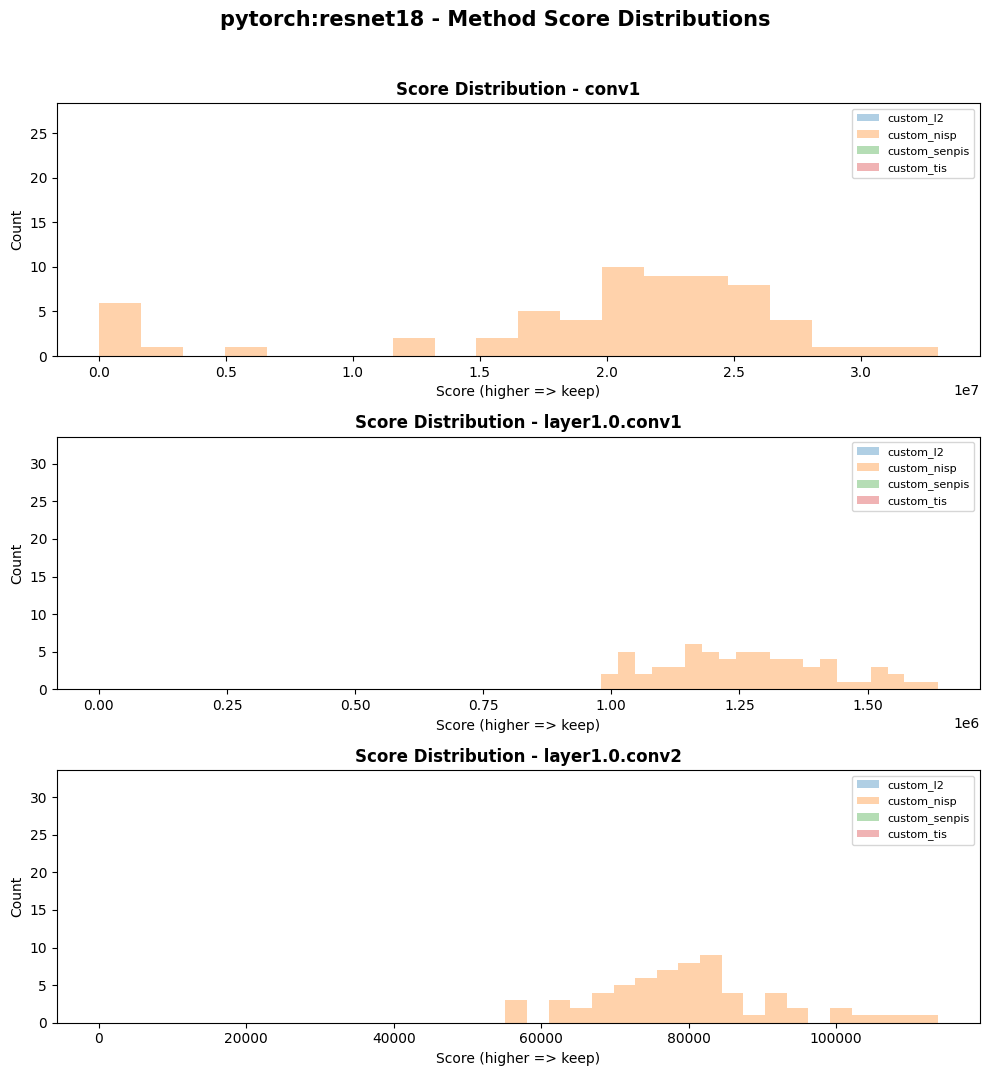

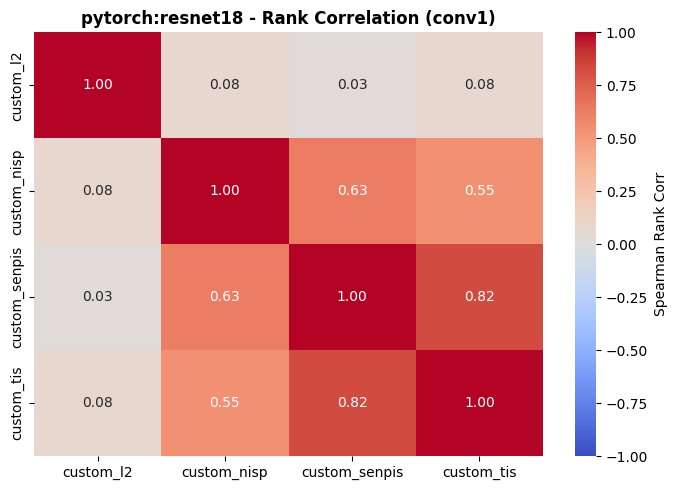

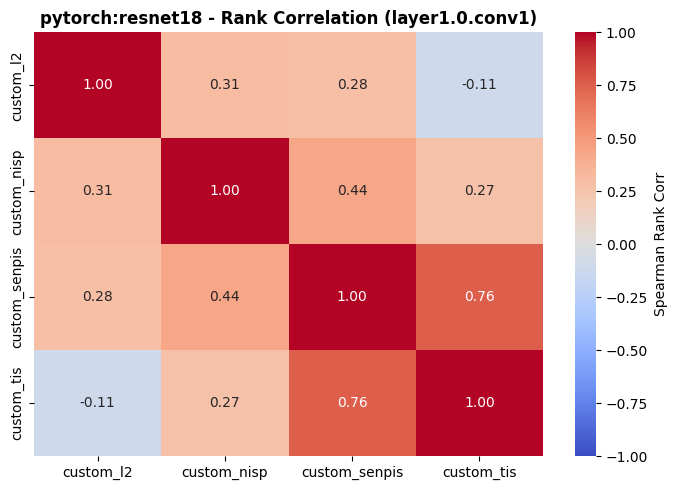

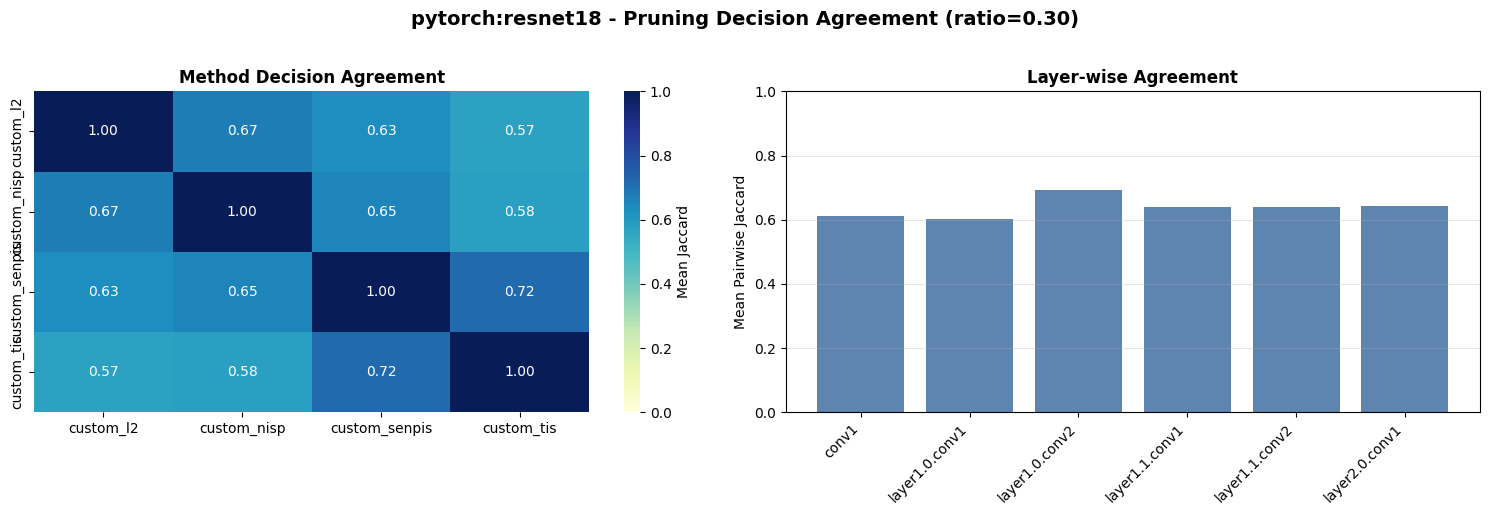

📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'custom_nisp' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/pytorch/cifar-10/resnet18/custom_nisp/20260324_110633_pytorch_resnet18_custom_nisp_deep_raw.pth
[timer] prune took 0.32s


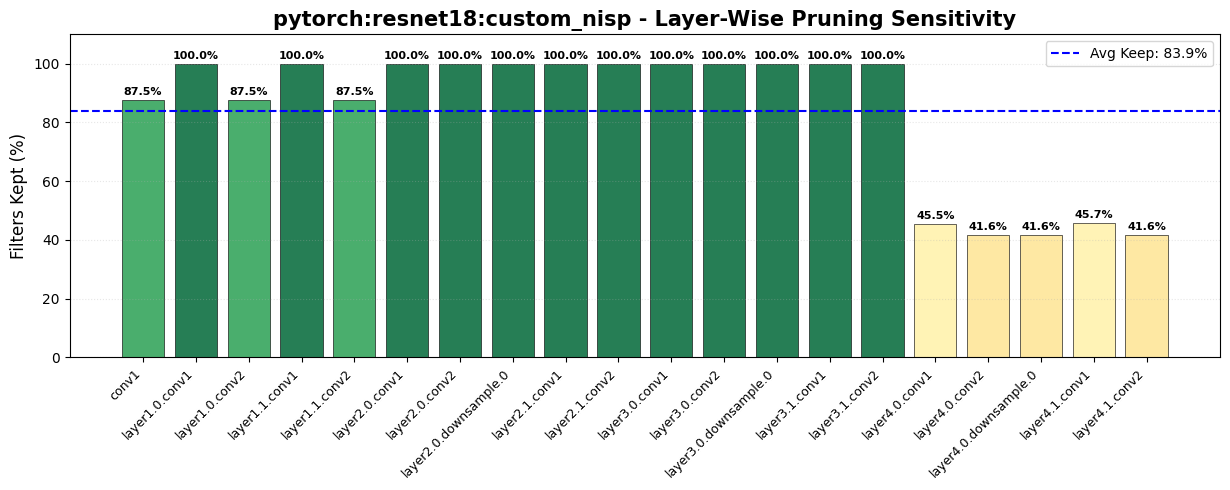

[pytorch_resnet18_custom_nisp_healing] Epoch 1/3: 100%|██████████| 64/64 [00:03<00:00, 16.36it/s, loss=0.2242, acc=94.75%]


[val] Loss 0.1300, Acc 96.90%


[pytorch_resnet18_custom_nisp_healing] Epoch 2/3: 100%|██████████| 64/64 [00:03<00:00, 17.01it/s, loss=0.0262, acc=99.76%]


[val] Loss 0.1091, Acc 97.80%


[pytorch_resnet18_custom_nisp_healing] Epoch 3/3: 100%|██████████| 64/64 [00:04<00:00, 15.18it/s, loss=0.0175, acc=99.98%] 


[val] Loss 0.1014, Acc 97.60%
[train] Restored best validation checkpoint (acc=97.80%).
[timer] train took 13.25s
Saved healed checkpoint: saved_models/fine_tuned/pytorch/cifar-10/resnet18/custom_nisp/20260324_110633_pytorch_resnet18_custom_nisp_healed.pth


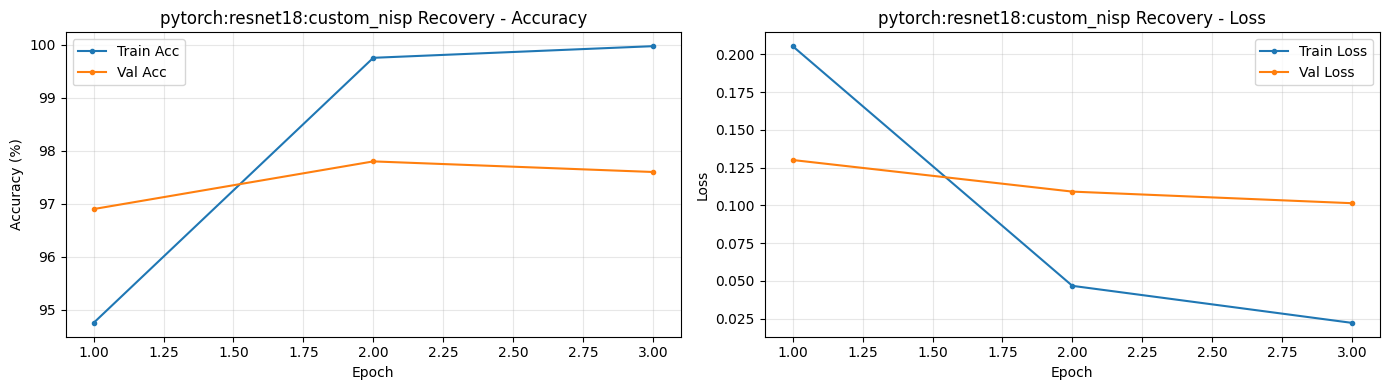

Accuracy Summary:
 - Baseline: 78.50%
 - Pruned:   38.15%
 - Healed:   89.40%

Metrics: Baseline vs Pruned


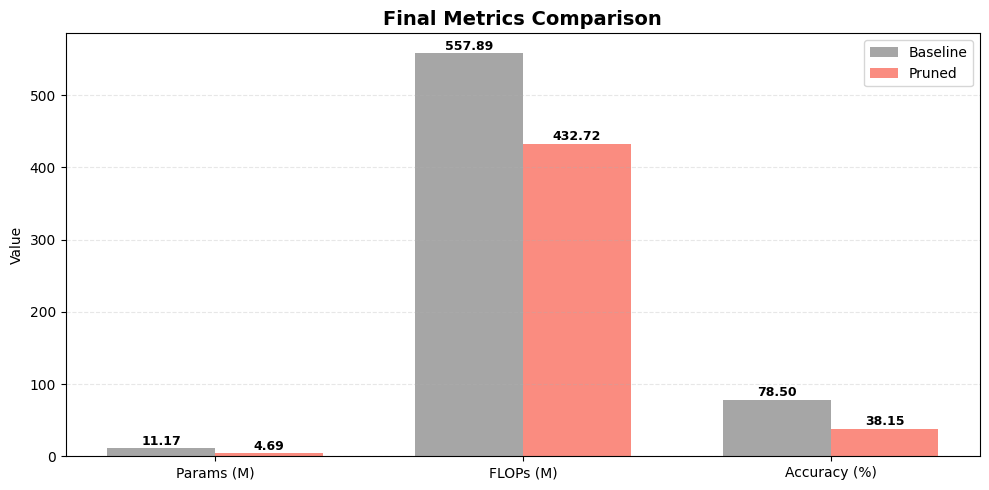

🚀 Business Impact: Model is 1.29x faster (FLOPs reduced by 22.4%).
📉 Accuracy Delta: +40.35%

Metrics: Baseline vs Healed


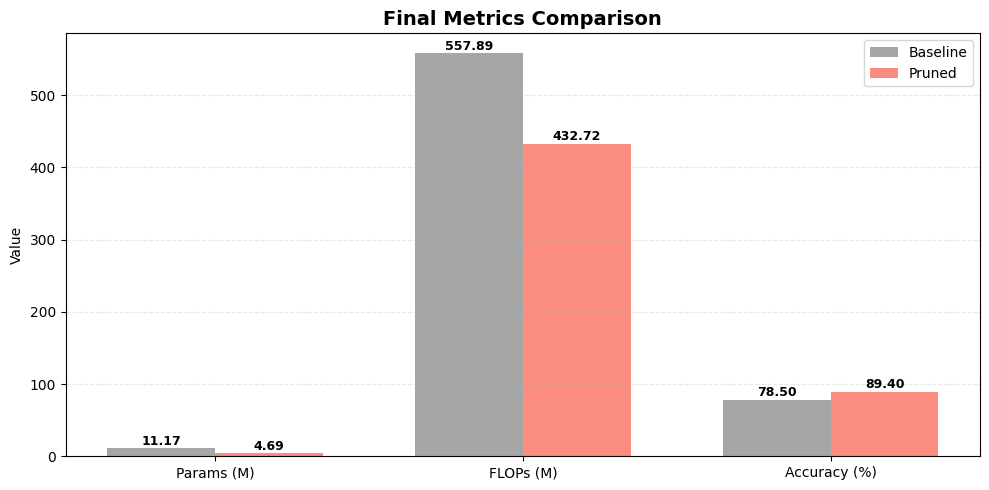

🚀 Business Impact: Model is 1.29x faster (FLOPs reduced by 22.4%).
📉 Accuracy Delta: -10.90%


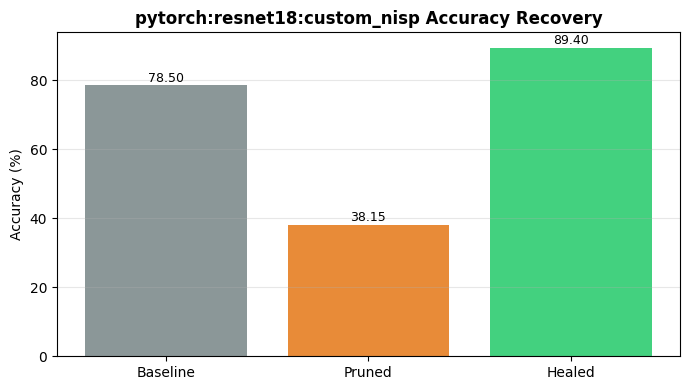

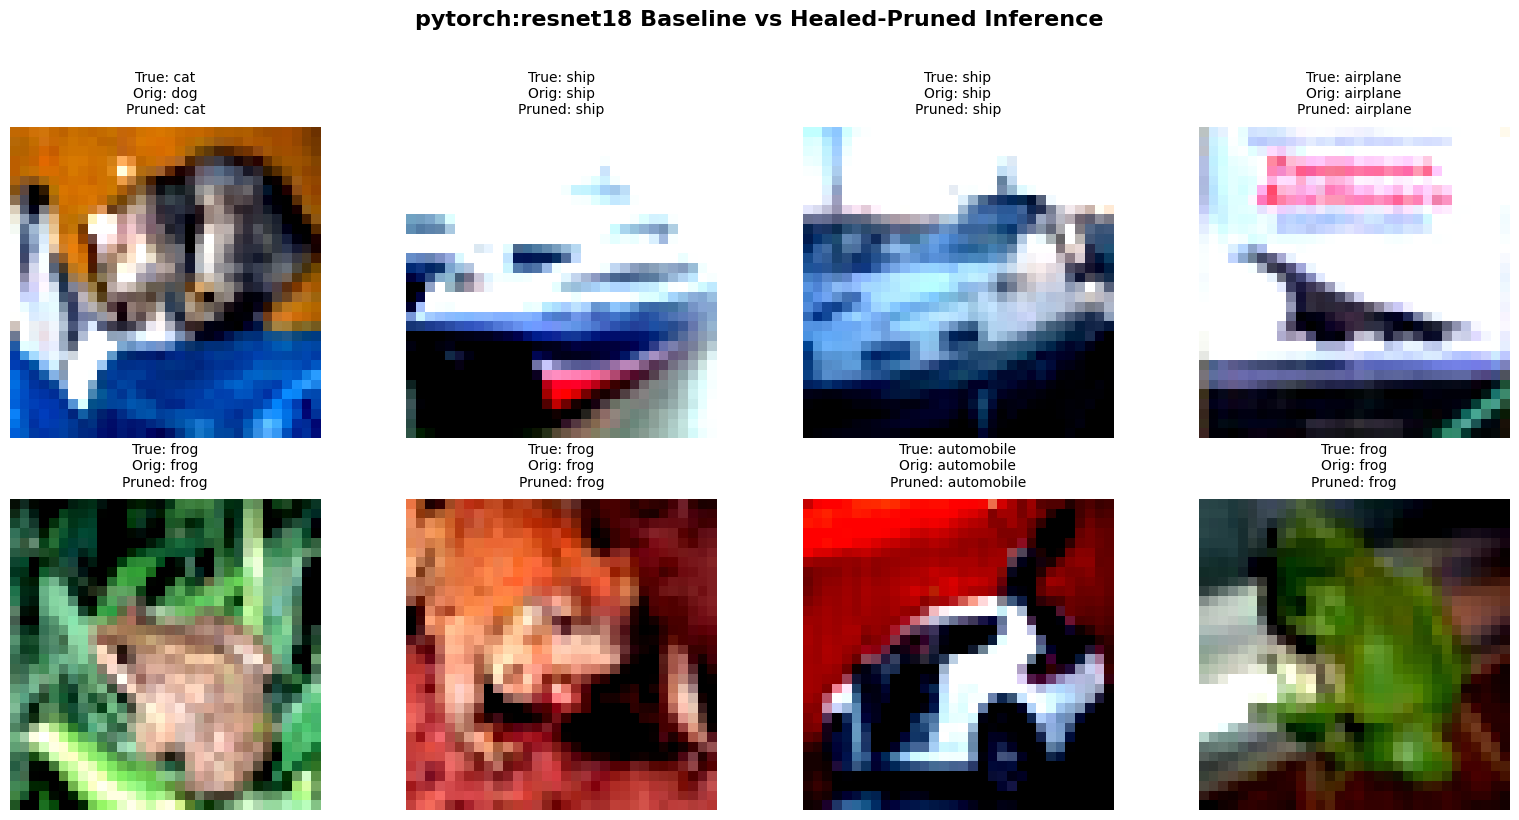


=== Deep Analysis [keras] method=custom_nisp ===


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 126 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded baseline checkpoint: saved_models/baselines/keras/cifar-10/resnet18/20260324_110633_keras_resnet18_baseline.weights.h5


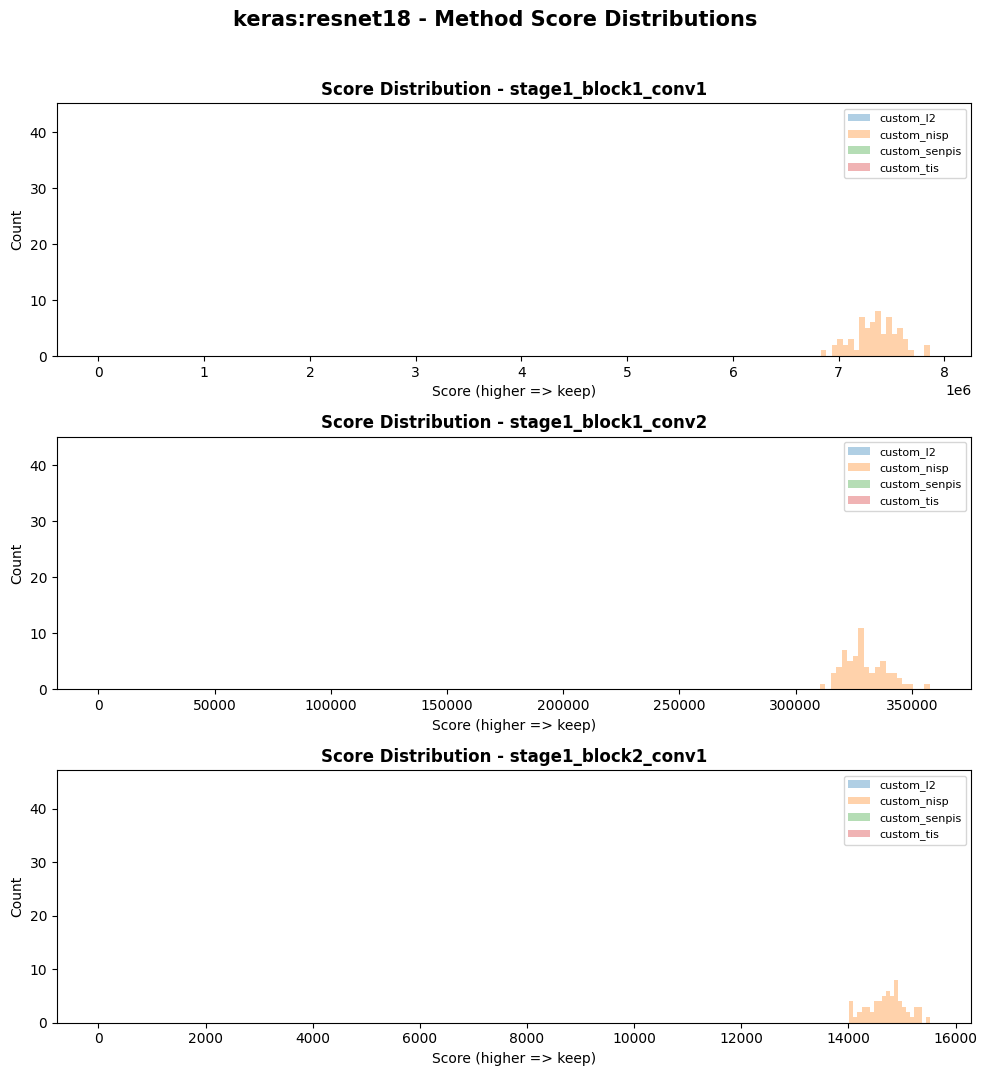

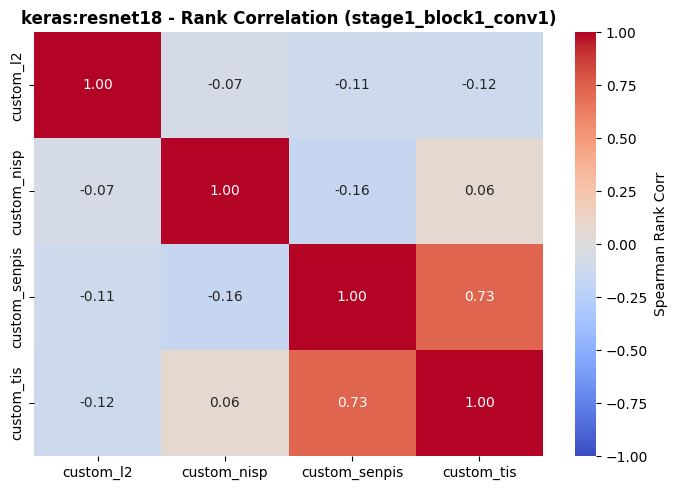

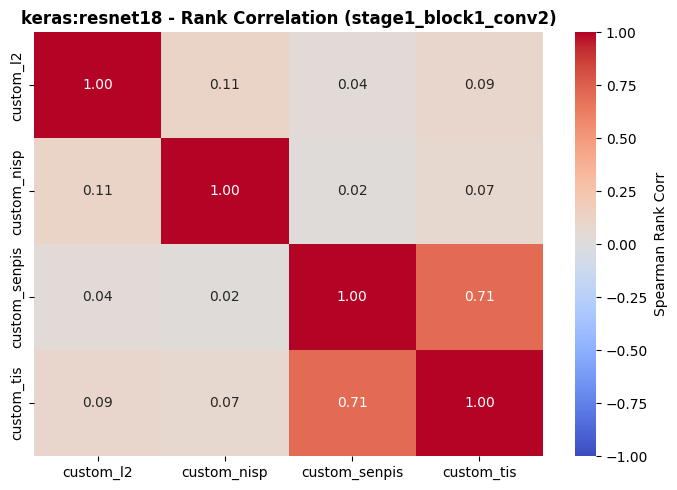

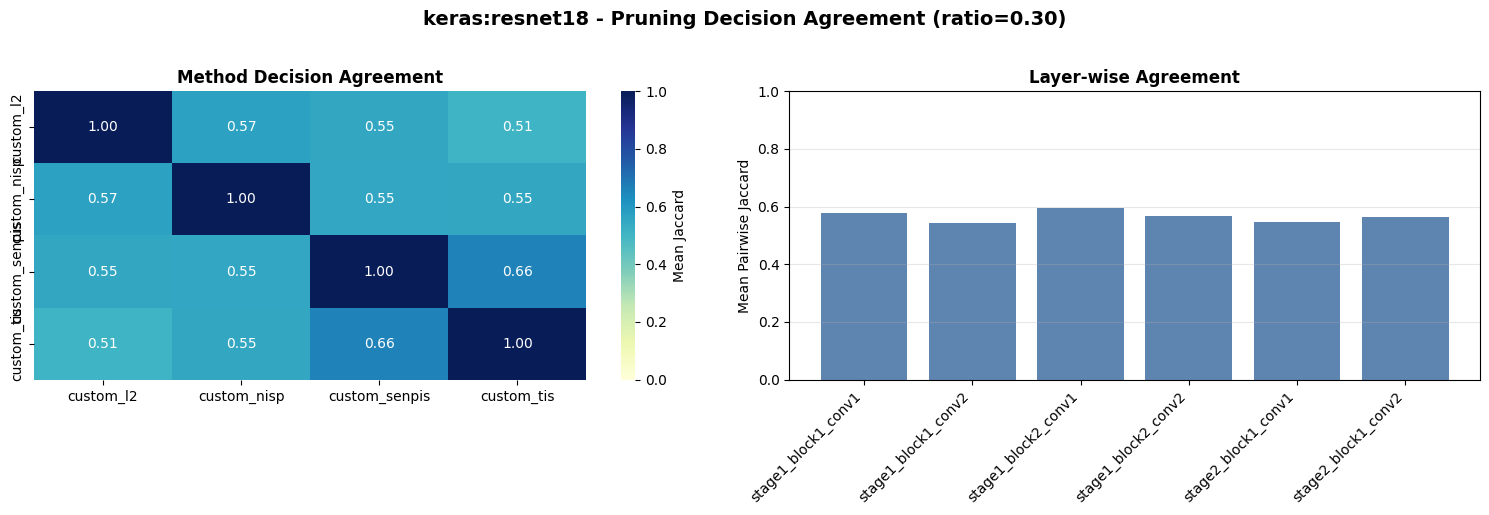

📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'custom_nisp' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/keras/cifar-10/resnet18/custom_nisp/20260324_110633_keras_resnet18_custom_nisp_deep_raw.weights.h5
[timer] prune took 1.56s


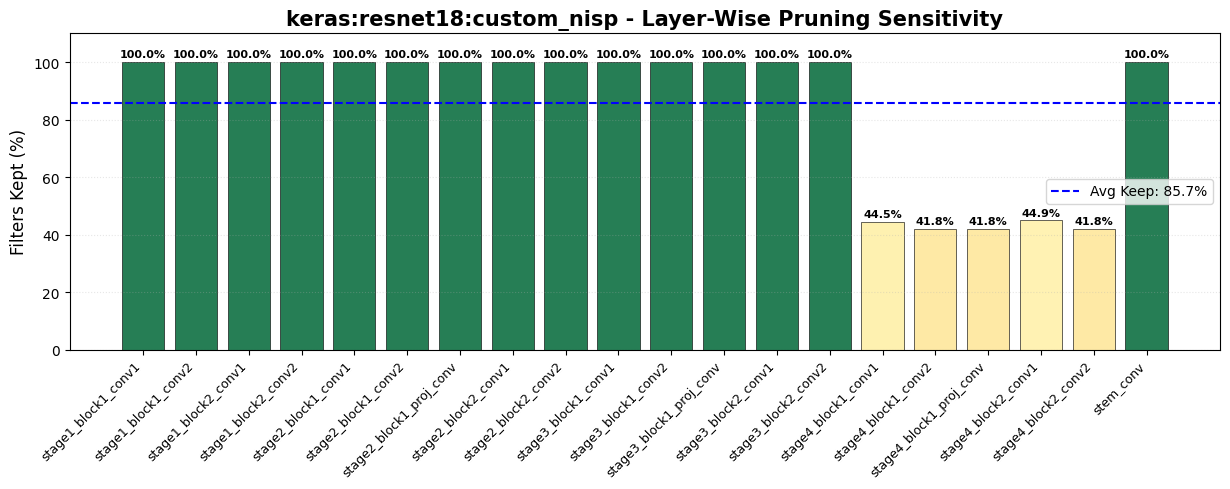

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3569 - loss: 1.7761[train] Epoch 1/3 - loss: 1.6641 - acc: 0.3972 - val_loss: 2.2456 - val_acc: 0.2350
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 78ms/step - accuracy: 0.3972 - loss: 1.6641 - val_accuracy: 0.2350 - val_loss: 2.2456 - learning_rate: 3.0000e-04
Epoch 2/3
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5886 - loss: 1.1501[train] Epoch 2/3 - loss: 1.1193 - acc: 0.6001 - val_loss: 1.9817 - val_acc: 0.3150
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6001 - loss: 1.1193 - val_accuracy: 0.3150 - val_loss: 1.9817 - learning_rate: 3.0000e-04
Epoch 3/3
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8233 - loss: 0.6125[train] Epoch 3/3 - loss: 0.5986 - acc: 0.8125 - val_loss: 2.3000 - val_acc: 0.2870

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8125 - loss: 0.5986 - val_accuracy: 0.2870 - val_loss: 2.3000 - learning_rate: 

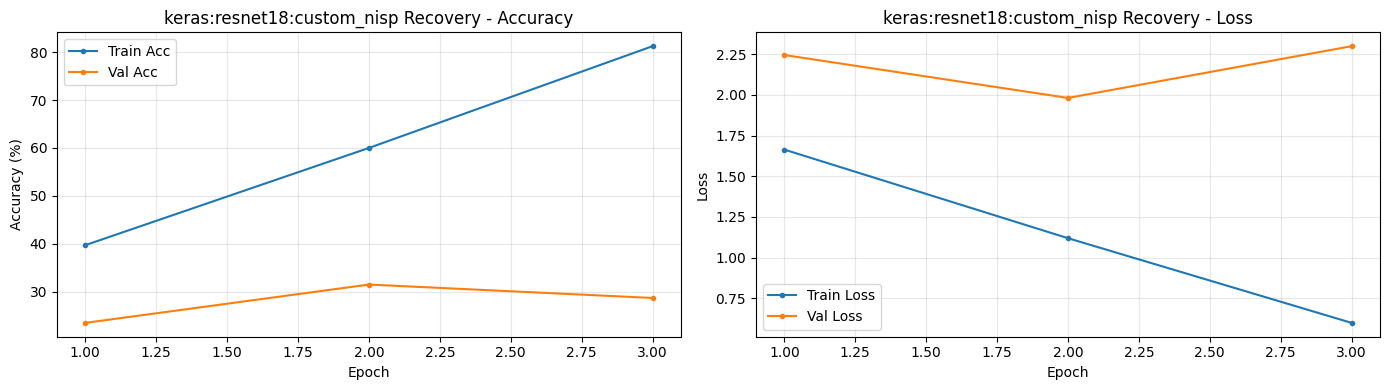

Accuracy Summary:
 - Baseline: 15.55%
 - Pruned:   16.00%
 - Healed:   27.75%

Metrics: Baseline vs Pruned


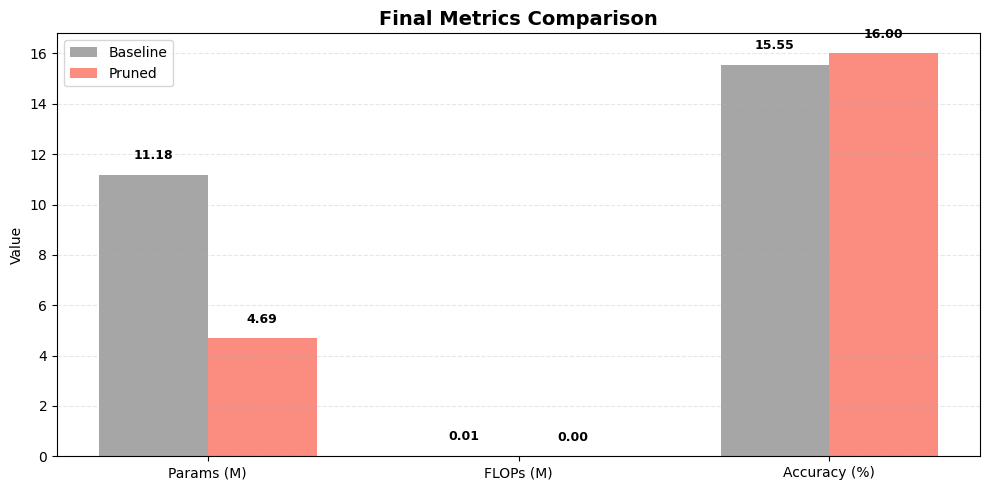

🚀 Business Impact: Model is 2.39x faster (FLOPs reduced by 58.2%).
📉 Accuracy Delta: -0.45%

Metrics: Baseline vs Healed


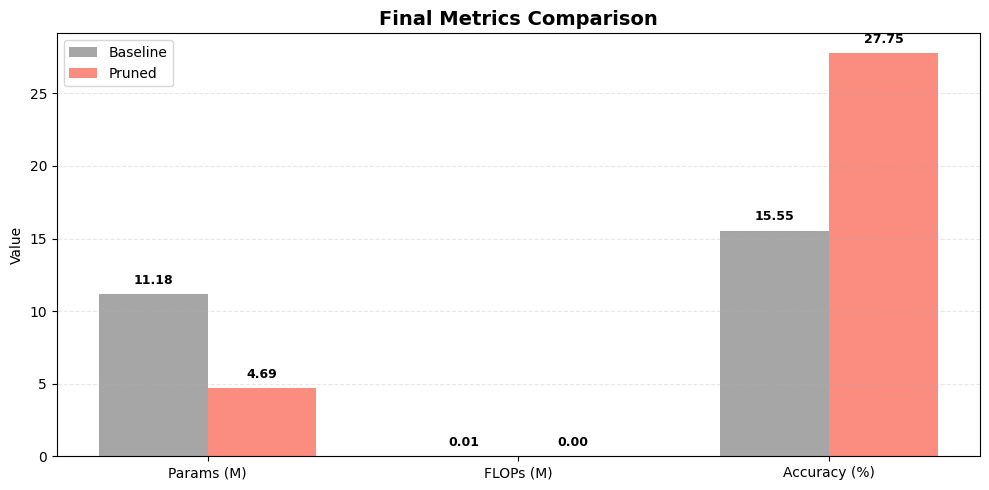

🚀 Business Impact: Model is 2.39x faster (FLOPs reduced by 58.2%).
📉 Accuracy Delta: -12.20%


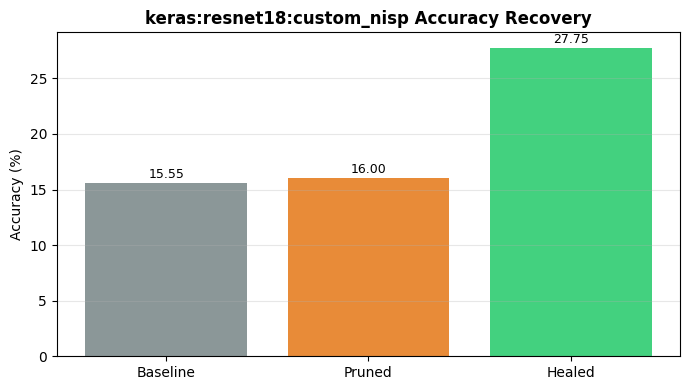

Instructions for updating:
Use tf.identity with explicit device placement instead.


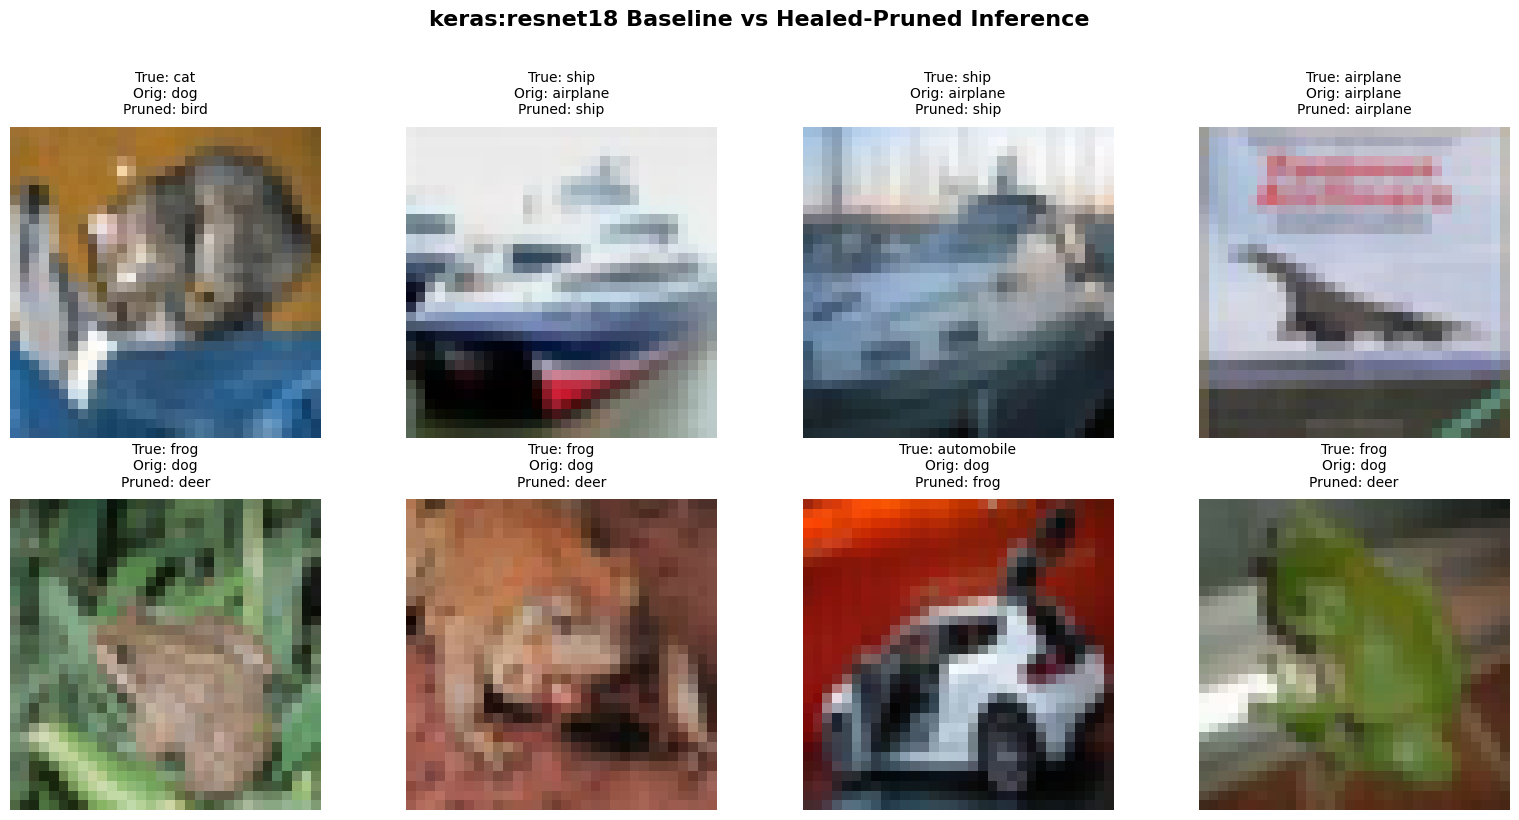

Saved: outputs/custom_method_matrix/deep_analysis_resnet18_custom_nisp_balanced_20260324_110633.csv


,backend,model,method,scope,prune_duration_sec,baseline_acc,pruned_acc,healed_acc,baseline_ckpt_used,raw_pruned_ckpt,healed_ckpt
0,pytorch,resnet18,custom_nisp,global,0.069331,78.500000,38.15,89.40,saved_models/baselines/pytorch/cifar-10/resnet...,saved_models/pruned_raw/pytorch/cifar-10/resne...,saved_models/fine_tuned/pytorch/cifar-10/resne...
1,keras,resnet18,custom_nisp,global,0.541306,15.549999,16.00,27.75,saved_models/baselines/keras/cifar-10/resnet18...,saved_models/pruned_raw/keras/cifar-10/resnet1...,saved_models/fine_tuned/keras/cifar-10/resnet1...


In [9]:
# Deep analysis: plots, healing, and baseline-vs-pruned-vs-healed comparison

def _stats_dict(adapter, model, loader, acc):
    flops, params = adapter.get_stats(model, loader)
    return {"FLOPs": float(flops), "Params": float(params), "Acc": float(acc)}


def _plot_accuracy_triplet(b_acc, p_acc, h_acc, title):
    labels = ["Baseline", "Pruned", "Healed"]
    vals = [float(b_acc), float(p_acc), float(h_acc)]
    colors = ["#7f8c8d", "#e67e22", "#2ecc71"]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, vals, color=colors, alpha=0.9)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2.0, h + 0.2, f"{h:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


def _safe_score_maps(adapter, model, loader, methods):
    out = {}
    for m in methods:
        try:
            out[m] = adapter.get_score_map(model, loader, m)
        except Exception as e:
            print(f"Skipping score-map method '{m}': {type(e).__name__}: {e}")
    return out


def _run_backend_analysis(backend: str):
    backend = backend.lower().strip()
    if backend == "pytorch":
        if "torch_adapter" not in globals():
            print("PyTorch run cell not executed yet; skipping deep analysis for PyTorch.")
            return None
        adapter = torch_adapter
        model_name = TORCH_MODEL_REQUEST
        calib_loader = torch_loader
        ckpt = torch_ckpt
        train_loader, val_loader, test_loader = make_torch_recovery_loaders()
        cfg = {"backend": "pytorch", "chip_max_spatial": CHIP_MAX_SPATIAL}
        input_shape = (3, 32, 32)
    elif backend == "keras":
        if "keras_adapter" not in globals():
            print("Keras run cell not executed yet; skipping deep analysis for Keras.")
            return None
        adapter = keras_adapter
        model_name = KERAS_MODEL_REQUEST
        calib_loader = keras_loader
        ckpt = keras_ckpt
        train_loader, val_loader, test_loader = make_keras_recovery_loaders()
        cfg = {"backend": "keras", "chip_max_spatial": CHIP_MAX_SPATIAL}
        input_shape = (32, 32, 3)
    else:
        print(f"Unknown backend '{backend}', skipping")
        return None

    print(f"\n=== Deep Analysis [{backend}] method={ANALYSIS_METHOD} ===")

    baseline = adapter.get_model(model_name, input_shape=input_shape, num_classes=10, pretrained=False)
    if ckpt:
        adapter.load_checkpoint(baseline, ckpt)
        print(f"Loaded baseline checkpoint: {ckpt}")

    baseline_acc = float(adapter.evaluate(baseline, test_loader))

    score_maps = _safe_score_maps(adapter, baseline, calib_loader, ANALYSIS_COMPARE_METHODS)
    if score_maps:
        plot_score_distributions(score_maps, title_prefix=f"{backend}:{model_name}")
        if len(score_maps) >= 2:
            plot_rank_correlation(score_maps, title_prefix=f"{backend}:{model_name}")
            plot_decision_agreement(score_maps, ratio=PRUNE_RATIO, title_prefix=f"{backend}:{model_name}")

    scope = "global" if ANALYSIS_METHOD in GLOBAL_METHODS else "local"
    pruner = ReduCNNPruner(method=ANALYSIS_METHOD, scope=scope, config=cfg)

    raw_ckpt = build_checkpoint_path(
        stage="pruned_raw",
        backend=backend,
        model_name=model_name,
        method=ANALYSIS_METHOD,
        suffix="deep_raw",
        run_stamp=RUN_STAMP,
    ) if SAVE_RAW_PRUNED_CHECKPOINTS else None

    pruned_model, masks, prune_duration = pruner.prune_custom_model(
        baseline,
        calib_loader,
        ratio=PRUNE_RATIO,
        save_pruned_path=raw_ckpt,
    )

    pruned_acc = float(adapter.evaluate(pruned_model, test_loader))
    plot_layer_sensitivity(masks, title_prefix=f"{backend}:{model_name}:{ANALYSIS_METHOD}")

    history = adapter.train(
        pruned_model,
        train_loader,
        epochs=FINETUNE_EPOCHS,
        val_loader=val_loader,
        name=f"{backend}_{model_name}_{ANALYSIS_METHOD}_healing",
        plot=False,
    )

    healed_ckpt = ""
    if SAVE_HEALED_CHECKPOINTS:
        healed_ckpt = build_checkpoint_path(
            stage="fine_tuned",
            backend=backend,
            model_name=model_name,
            method=ANALYSIS_METHOD,
            suffix="healed",
            run_stamp=RUN_STAMP,
        )
        adapter.save_checkpoint(pruned_model, healed_ckpt)
        print(f"Saved healed checkpoint: {healed_ckpt}")

    healed_acc = float(adapter.evaluate(pruned_model, test_loader))
    plot_training_history(history, title=f"{backend}:{model_name}:{ANALYSIS_METHOD} Recovery")

    baseline_stats = _stats_dict(adapter, baseline, test_loader, baseline_acc)
    pruned_stats = _stats_dict(adapter, pruned_model, test_loader, pruned_acc)
    healed_stats = _stats_dict(adapter, pruned_model, test_loader, healed_acc)

    print("Accuracy Summary:")
    print(f" - Baseline: {baseline_acc:.2f}%")
    print(f" - Pruned:   {pruned_acc:.2f}%")
    print(f" - Healed:   {healed_acc:.2f}%")

    print("\nMetrics: Baseline vs Pruned")
    plot_metrics_comparison(baseline_stats, pruned_stats)
    print("\nMetrics: Baseline vs Healed")
    plot_metrics_comparison(baseline_stats, healed_stats)

    _plot_accuracy_triplet(
        baseline_acc,
        pruned_acc,
        healed_acc,
        title=f"{backend}:{model_name}:{ANALYSIS_METHOD} Accuracy Recovery",
    )

    try:
        plot_inference_gallery(
            baseline,
            pruned_model,
            test_loader,
            num_images=8,
            class_names=CLASS_NAMES,
            title=f"{backend}:{model_name} Baseline vs Healed-Pruned Inference",
        )
    except Exception as e:
        print(f"Inference gallery skipped: {type(e).__name__}: {e}")

    return {
        "backend": backend,
        "model": model_name,
        "method": ANALYSIS_METHOD,
        "scope": scope,
        "prune_duration_sec": float(prune_duration),
        "baseline_acc": float(baseline_acc),
        "pruned_acc": float(pruned_acc),
        "healed_acc": float(healed_acc),
        "baseline_ckpt_used": ckpt or "",
        "raw_pruned_ckpt": raw_ckpt or "",
        "healed_ckpt": healed_ckpt or "",
    }


analysis_records = []
if RUN_DEEP_ANALYSIS:
    for b in ANALYSIS_BACKENDS:
        rec = _run_backend_analysis(b)
        if rec is not None:
            analysis_records.append(rec)

analysis_df = pd.DataFrame(analysis_records)
if not analysis_df.empty:
    report_dir = Path("outputs/custom_method_matrix")
    report_dir.mkdir(parents=True, exist_ok=True)
    analysis_path = report_dir / f"deep_analysis_{MODEL_TARGET}_{ANALYSIS_METHOD}_{EXPERIMENT_PRESET}_{RUN_STAMP}.csv"
    analysis_df.to_csv(analysis_path, index=False)
    print("Saved:", analysis_path)

analysis_df


## Notes

- Normal user workflow: define method math + `@register_method(...)`; backend handles most heavy lifting.
- Real-run quality is controlled by `EXPERIMENT_PRESET`.
- `chip` is computationally expensive, especially on deeper models.
- Deep analysis section adds:
  - layer sensitivity plots
  - score/rank/decision method comparisons
  - healing (fine-tuning) curves
  - baseline vs pruned vs healed metric comparison
  - inference gallery comparison
